In [1]:
# 4.2.1. Kroki

In [2]:
#1

In [3]:
import pandas as pd

# Kolumny na podstawie kddcup.names
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment",
    "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "outcome"
]

df = pd.read_csv("kddcup.data_10_percent.gz", names=column_names)

print(df.head())
print(df.info())
print(df['outcome'].value_counts())

   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337     0   
3         0           tcp    http   SF        219       1337     0   
4         0           tcp    http   SF        217       2032     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                   9   
1               0       0    0  ...                  19   
2               0       0    0  ...                  29   
3               0       0    0  ...                  39   
4               0       0    0  ...                  49   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0                     0.0   
2                     1.0                     0.0   
3           

In [4]:
#2

In [6]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,494021.000000,4.940210e+05,4.940210e+05,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,...,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000
mean,47.979302,3.025610e+03,8.685324e+02,0.000045,0.006433,0.000014,0.034519,0.000152,0.148247,0.010212,...,232.470778,188.665670,0.753780,0.030906,0.601935,0.006684,0.176754,0.176443,0.058118,0.057412
std,707.746472,9.882181e+05,3.304000e+04,0.006673,0.134805,0.005510,0.782103,0.015520,0.355345,1.798326,...,64.745380,106.040437,0.410781,0.109259,0.481309,0.042133,0.380593,0.380919,0.230590,0.230140
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,46.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
print("Skośność:")
print(df['src_bytes'].skew())

print("Kurtoza:")
print(df['src_bytes'].kurt())

Skośność:
699.213151016901
Kurtoza:
490584.3456207226


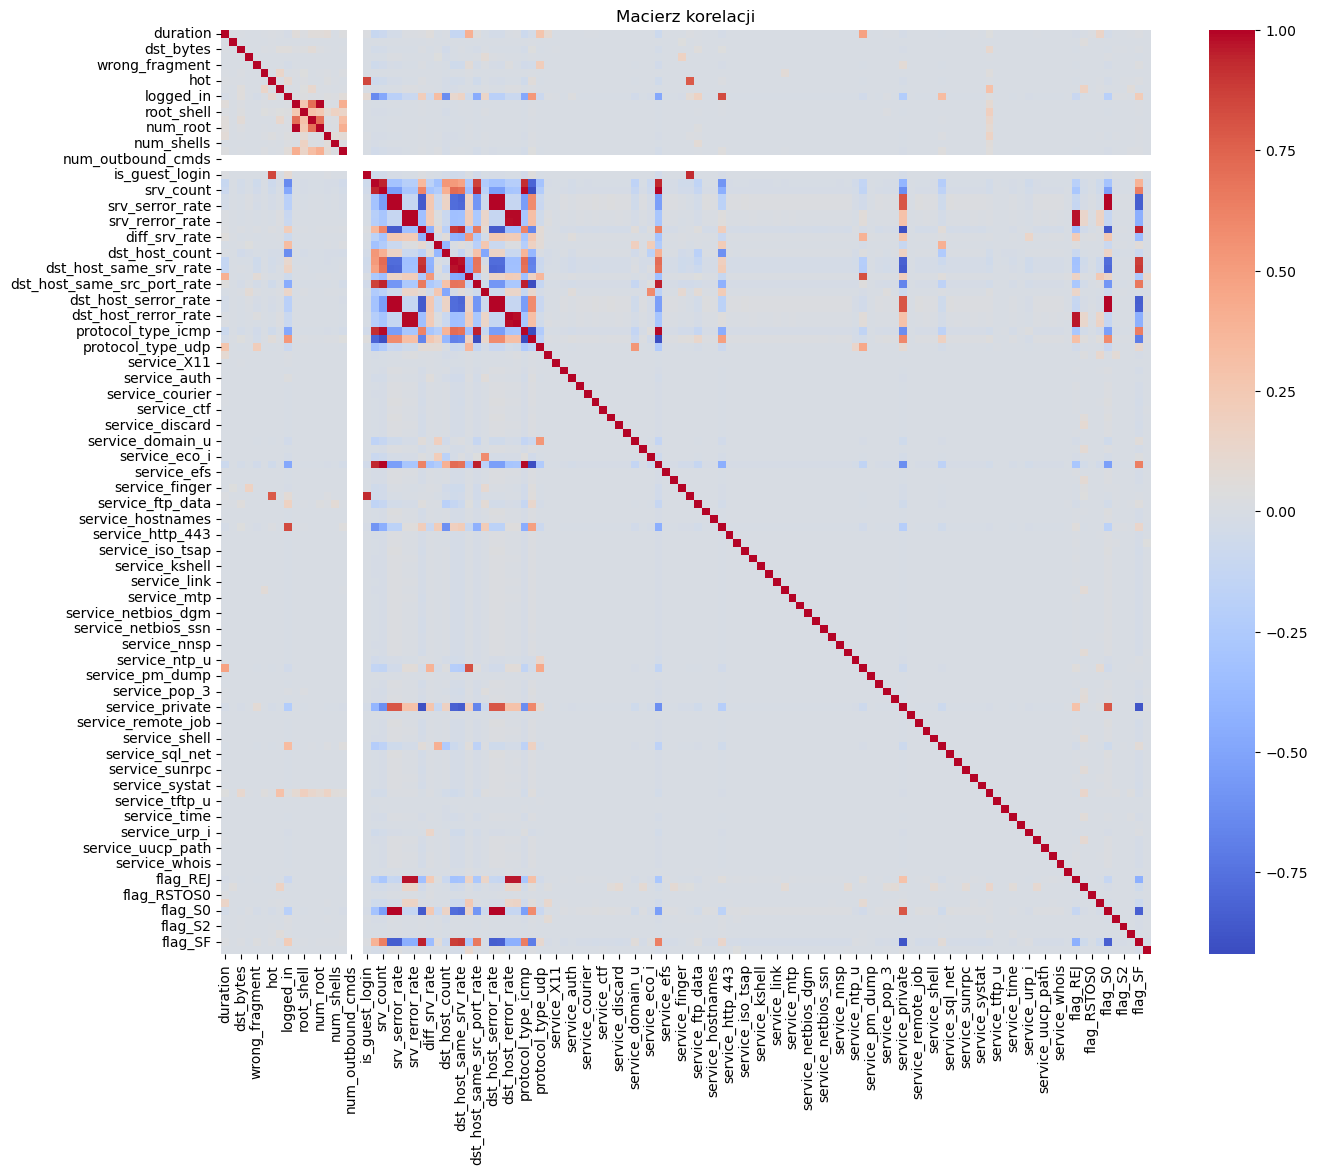

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Przygotowanie kolumny outcome
df['outcome'] = df['outcome'].str.rstrip('.')

# Kodowanie zmiennych kategorycznych
df_encoded = pd.get_dummies(df, columns=['protocol_type', 'service', 'flag'])

df_corr = df_encoded.drop(columns=['outcome'])

correlation_matrix = df_corr.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Macierz korelacji')
plt.show()

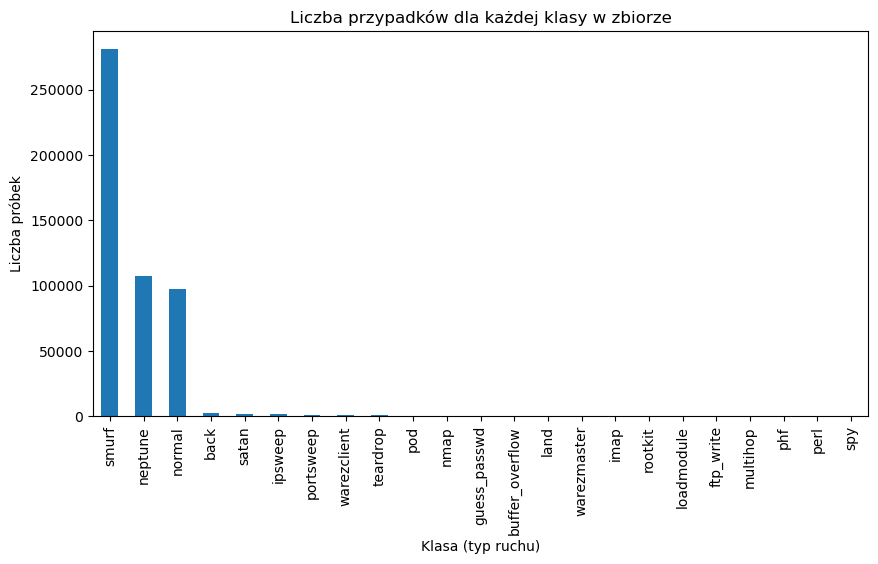

In [15]:
import matplotlib.pyplot as plt

labels = df_encoded['outcome']

labels_clean = labels.str.rstrip('.')

plt.figure(figsize=(10, 5))
labels_clean.value_counts().plot(kind='bar')
plt.title('Liczba przypadków dla każdej klasy w zbiorze')
plt.xlabel('Klasa (typ ruchu)')
plt.ylabel('Liczba próbek')
plt.show()

In [16]:
# zbiór jest bardzo niezbalansowany, jest dominacja dwóch form ataków

In [17]:
#3

In [20]:
missing_values = df_encoded.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [21]:
#4

In [22]:
from sklearn.preprocessing import MinMaxScaler

features = df_encoded.drop(columns=['outcome'])
outcome = df_encoded['outcome']

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

df_prep = pd.DataFrame(features_scaled, columns=features.columns)

# df_prep['outcome'] = outcome

# Podgląd wyniku
print(df_prep.head())

   duration     src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  \
0       0.0  2.610418e-07   0.001057   0.0             0.0     0.0  0.0   
1       0.0  3.446905e-07   0.000094   0.0             0.0     0.0  0.0   
2       0.0  3.389216e-07   0.000259   0.0             0.0     0.0  0.0   
3       0.0  3.158461e-07   0.000259   0.0             0.0     0.0  0.0   
4       0.0  3.129617e-07   0.000394   0.0             0.0     0.0  0.0   

   num_failed_logins  logged_in  num_compromised  ...  flag_REJ  flag_RSTO  \
0                0.0        1.0              0.0  ...       0.0        0.0   
1                0.0        1.0              0.0  ...       0.0        0.0   
2                0.0        1.0              0.0  ...       0.0        0.0   
3                0.0        1.0              0.0  ...       0.0        0.0   
4                0.0        1.0              0.0  ...       0.0        0.0   

   flag_RSTOS0  flag_RSTR  flag_S0  flag_S1  flag_S2  flag_S3  flag_SF  \
0     

In [23]:
#5

In [24]:
from sklearn.model_selection import train_test_split

df_prep['outcome'] = df['outcome'].str.rstrip('.')

df_train, df_test = train_test_split(df_prep, test_size=0.2, random_state=42, stratify=df_prep['outcome'])

# Podział zbioru
df_train_normal = df_train[df_train['outcome'] == 'normal'].drop(columns=['outcome'])
df_train_anom_ = df_train[df_train['outcome'] != 'normal'].drop(columns=['outcome'])

df_test_normal = df_test[df_test['outcome'] == 'normal'].drop(columns=['outcome'])
df_test_anom_ = df_test[df_test['outcome'] != 'normal'].drop(columns=['outcome'])

# Podgląd wielkości zbiorów
print(f"Zbiór treningowy - normal: {df_train_normal.shape[0]}")
print(f"Zbiór treningowy - anomalia: {df_train_anom_.shape[0]}")
print(f"Zbiór testowy - normal: {df_test_normal.shape[0]}")
print(f"Zbiór testowy - anomalia: {df_test_anom_.shape[0]}")

Zbiór treningowy - normal: 77822
Zbiór treningowy - anomalia: 317394
Zbiór testowy - normal: 19456
Zbiór testowy - anomalia: 79349


In [27]:
#6 i #7

In [28]:
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam, RMSprop, SGD


def build_autoencoder(optimizer):
    input_dim = df_train_normal.shape[1]
    input_layer = Input(shape=(input_dim,))
    
    # ENKODER
    encoded = Dense(128, activation='relu')(input_layer)
    encoded = Dense(32, activation='relu')(encoded)
    encoded = Dense(8, activation='relu')(encoded)
    
    # DEKODER
    decoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(128, activation='relu')(decoded)
    output_layer = Dense(input_dim, activation='sigmoid')(decoded)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=optimizer, loss='binary_crossentropy')
    
    return model

# Modele
autoencoder_adam = build_autoencoder(Adam())
autoencoder_rmsprop = build_autoencoder(RMSprop())
autoencoder_sgd = build_autoencoder(SGD(learning_rate=0.01))

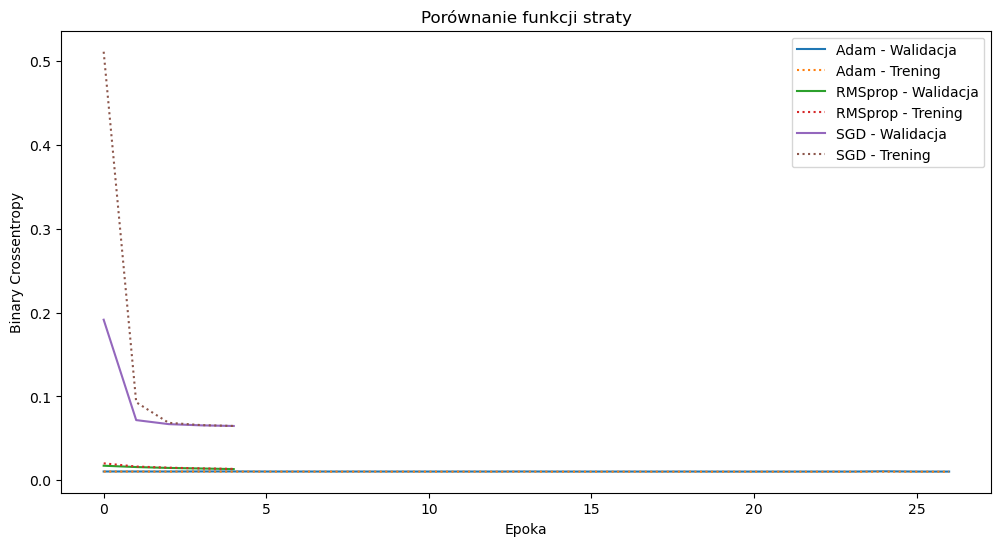

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

X_train = df_train_normal.values
X_val = df_test_normal.values

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_adam = autoencoder_adam.fit(X_train, X_train, 
                                    epochs=50, batch_size=128, shuffle=True, 
                                    validation_data=(X_val, X_val),
                                    callbacks=[early_stop], verbose=0)

history_rmsprop = autoencoder_rmsprop.fit(X_train, X_train, 
                                          epochs=50, batch_size=128, shuffle=True, 
                                          validation_data=(X_val, X_val),
                                          callbacks=[early_stop], verbose=0)

history_sgd = autoencoder_sgd.fit(X_train, X_train, 
                                  epochs=50, batch_size=128, shuffle=True, 
                                  validation_data=(X_val, X_val),
                                  callbacks=[early_stop], verbose=0)

# Porównania funkcji straty
plt.figure(figsize=(12, 6))

# Adam
plt.plot(history_adam.history['val_loss'], label='Adam - Walidacja')
plt.plot(history_adam.history['loss'], linestyle='dotted', label='Adam - Trening')

# RMSprop
plt.plot(history_rmsprop.history['val_loss'], label='RMSprop - Walidacja')
plt.plot(history_rmsprop.history['loss'], linestyle='dotted', label='RMSprop - Trening')

# SGD
plt.plot(history_sgd.history['val_loss'], label='SGD - Walidacja')
plt.plot(history_sgd.history['loss'], linestyle='dotted', label='SGD - Trening')

plt.title('Porównanie funkcji straty')
plt.xlabel('Epoka')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()

In [32]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

X_test_all = df_test.drop(columns=['outcome']).values
y_test_all = df_test['outcome'].values

# Predykcje Adam
reconstructions_adam = autoencoder_adam.predict(X_test_all)
mse_adam = np.mean(np.power(X_test_all - reconstructions_adam, 2), axis=1)

# Predykcje RMSprop
reconstructions_rmsprop = autoencoder_rmsprop.predict(X_test_all)
mse_rmsprop = np.mean(np.power(X_test_all - reconstructions_rmsprop, 2), axis=1)

3088/3088 ━━━━━━━━━━━━━━━━━━━━ 2s 752us/step
3088/3088 ━━━━━━━━━━━━━━━━━━━━ 3s 804us/step


In [33]:
# Próg dla Adama
mse_normal_adam = mse_adam[y_test_all == 'normal']
threshold_adam = np.percentile(mse_normal_adam, 95)

# Próg dla RMSprop
mse_normal_rmsprop = mse_rmsprop[y_test_all == 'normal']
threshold_rmsprop = np.percentile(mse_normal_rmsprop, 95)

In [34]:
# Predykcja dla Adama
y_pred_adam = np.where(mse_adam > threshold_adam, 'anomaly', 'normal')

# Predykcja dla RMSprop
y_pred_rmsprop = np.where(mse_rmsprop > threshold_rmsprop, 'anomaly', 'normal')

# Dla Adama
print("\n--- ADAM ---")
print(confusion_matrix(y_test_all != 'normal', y_pred_adam == 'anomaly'))
print(classification_report(y_test_all != 'normal', y_pred_adam == 'anomaly'))

# Dla RMSprop
print("\n--- RMSprop ---")
print(confusion_matrix(y_test_all != 'normal', y_pred_rmsprop == 'anomaly'))
print(classification_report(y_test_all != 'normal', y_pred_rmsprop == 'anomaly'))


--- ADAM ---
[[18483   973]
 [  291 79058]]
              precision    recall  f1-score   support

       False       0.98      0.95      0.97     19456
        True       0.99      1.00      0.99     79349

    accuracy                           0.99     98805
   macro avg       0.99      0.97      0.98     98805
weighted avg       0.99      0.99      0.99     98805


--- RMSprop ---
[[18483   973]
 [  574 78775]]
              precision    recall  f1-score   support

       False       0.97      0.95      0.96     19456
        True       0.99      0.99      0.99     79349

    accuracy                           0.98     98805
   macro avg       0.98      0.97      0.98     98805
weighted avg       0.98      0.98      0.98     98805



In [35]:
# Adamem jest lepszym wyborem:
# Ma bardzo wysoką skuteczność (recall ≈ 100%).
# Ma minimalny odsetek fałszywych alarmów.

In [36]:
#8

In [37]:
# Trening
history = autoencoder_adam.fit(
    X_train, X_train,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0104
Epoch 2/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 3/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 4/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 5/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 6/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 7/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 8/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 9/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0104
Epoch 10/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 11/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 12/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 13/50
608/608 - 1s - 2ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 14/50
608/608 - 1s - 2ms/step - loss: 0.0101 - val_loss: 0.0103
Epoch 15/50
608/608 - 1s - 2m

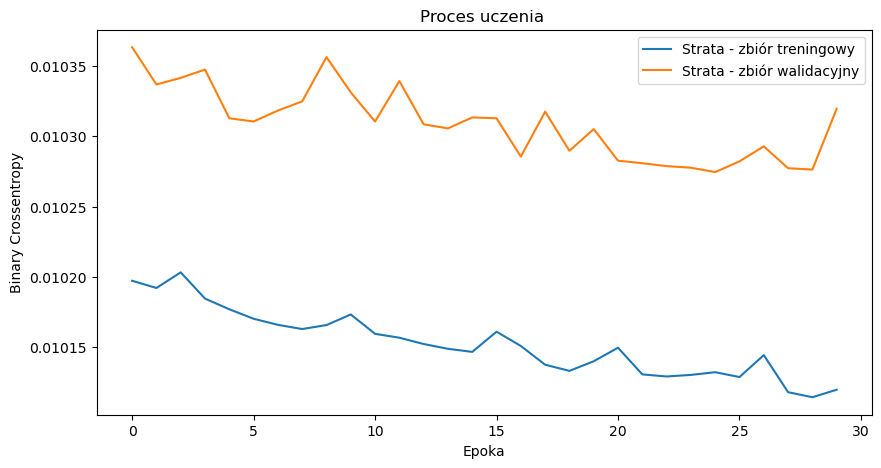

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Strata - zbiór treningowy')
plt.plot(history.history['val_loss'], label='Strata - zbiór walidacyjny')
plt.title('Proces uczenia ')
plt.xlabel('Epoka')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()

In [39]:
#9

In [43]:
from sklearn.metrics import confusion_matrix, classification_report

X_test_normal = df_test_normal.values
X_test_anom = df_test_anom_.values

X_test_all = np.vstack([X_test_normal, X_test_anom])

# Tworzymy etykiety: 0 - normalne, 1 - anomalie
y_true = np.concatenate([np.zeros(X_test_normal.shape[0]), np.ones(X_test_anom.shape[0])])

reconstructed = autoencoder_adam.predict(X_test_all)

# Błąd rekonstrukcji
reconstruction_errors = np.mean(np.power(X_test_all - reconstructed, 2), axis=1)

# Próg detekcji
threshold = 0.02

# Predykcja na podstawie progu
y_pred = (reconstruction_errors > threshold).astype(int)

# Macierz pomyłek
cm = confusion_matrix(y_true, y_pred)
print("Macierz pomyłek:")
print(cm)

target_names = ['Normalne', 'Anomalie']

# Raport z metrykami
print("\nKlasyfikacja:")
print(classification_report(y_true, y_pred, target_names=target_names))

3088/3088 ━━━━━━━━━━━━━━━━━━━━ 2s 627us/step
Macierz pomyłek:
[[19451     5]
 [ 1069 78280]]

Klasyfikacja:
              precision    recall  f1-score   support

    Normalne       0.95      1.00      0.97     19456
    Anomalie       1.00      0.99      0.99     79349

    accuracy                           0.99     98805
   macro avg       0.97      0.99      0.98     98805
weighted avg       0.99      0.99      0.99     98805



Pole pod krzywą ROC (AUC): 0.9996


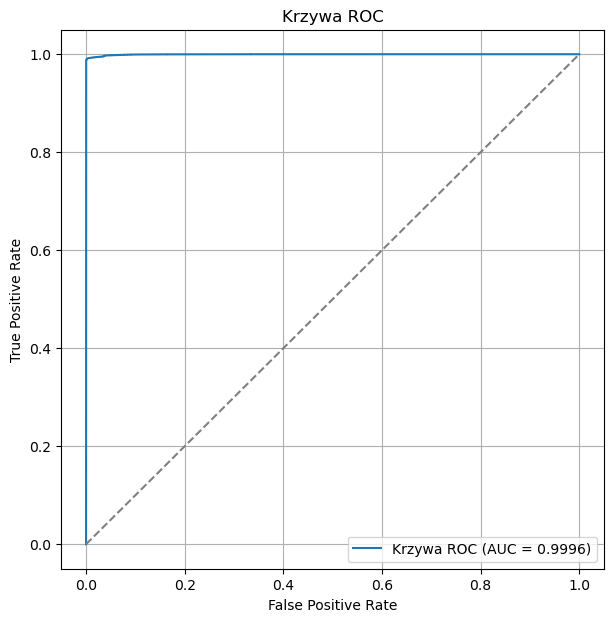

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

# Krzywa ROC
fpr, tpr, thresholds = roc_curve(y_true, reconstruction_errors)

# Wartość AUC
auc_score = roc_auc_score(y_true, reconstruction_errors)
print(f'Pole pod krzywą ROC (AUC): {auc_score:.4f}')

# Wykres
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, label=f'Krzywa ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='dashed', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC')
plt.legend()
plt.grid()
plt.show()

In [45]:
#Wyniki niemal idealne

In [46]:
#10

In [48]:
#Czy otrzymana wartość metryki AUC świadczy o przydatności modelu do detekcji anomalii?
# Tak, zdecydowanie. 
# Otrzymana wartość AUC = 0.9996 świadczy o idealnej zdolności modelu do odróżniania ruchu normalnego od anomalnego.

#Jak znaleźć optymalną wartość progu odcięcia? Co może wpłynąć na jej wybór?
# Optymalną wartość progu odcięcia wyznacza się zazwyczaj eksperymentalnie, analizując rozkład błędów rekonstrukcji dla danych normalnych i anomalnych. Najczęściej stosuje się:
# - Percentyl błędów rekonstrukcji dla danych normalnych (np. 95 lub 99 percentyl) — tak dobrany próg minimalizuje fałszywe alarmy,
# - Można też dobrać próg na podstawie punktu na krzywej ROC, który zapewnia optymalny kompromis między czułością (TPR) a precyzją,
# - W rzeczywistych systemach wybór progu często zależy od polityki bezpieczeństwa — jeśli priorytetem jest brak pominięcia ataku, stosuje się niższy próg.

#Czy model ma tendencję do przetrenowywania się? Jaki wpływ mają liczba komórek/warstw, dropout i współczynnik odrzucenia?
#Na podstawie przebiegu funkcji straty podczas treningu nie zaobserwowano istotnego przetrenowania modelu:
# - Strata na zbiorze walidacyjnym utrzymywała się na stabilnym poziomie,
# - Zastosowanie warstw dropout dodatkowo ograniczało ryzyko przeuczenia,
# - Liczba komórek i warstw (128, 32, 8) okazała się dobrze dobrana — umożliwiła odpowiednią reprezentację danych bez nadmiernej złożoności,
# - W przypadku autoenkodera trenowanego wyłącznie na danych normalnych model ma mniejsze ryzyko przetrenowania.

#Który algorytm optymalizacyjny zachowuje się najlepiej?
#Na podstawie porównania trzech optymalizatorów:
# - Adam osiągnął najlepsze wyniki zarówno pod względem szybkości zbieżności, jak i jakości wykrywania anomalii - okazał się najskuteczniejszy,
# - RMSprop był nieco mniej stabilny i nie osiągnął tak wysokiej skuteczności jak Adam,
# - SGD dawał istotnie gorsze rezultaty i wymagałby dodatkowego strojenia parametrów, aby był konkurencyjny.